# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [6]:
# Import necessary libraries
import os
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from collections import Counter
import json


import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

import sentence_transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.naive_bayes import MultinomialNB
import joblib
import keras_hub
import tensorflow as tf
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

import transformers
from sklearn.metrics.pairwise import cosine_similarity




#from transformers import AutoTokenizer, TFAutoModelForSeq2SeqLM


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

TODO: Load and explore the RealWaste dataset
- Dataset structure
- Distribution of waste categories
- Image characteristics (resolution, quality, background)

Your code here

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Define the path to the RealWaste dataset

data_dir = pathlib.Path(
    "/content/drive/MyDrive/WasteManagement/RealWaste"
)

print("Dataset folder exists:", data_dir.exists())

print("Dataset folders:", os.listdir(data_dir))

Dataset folder exists: True
Dataset folders: ['Food Organics', 'Plastic', 'Metal', 'Glass', 'Cardboard', 'Vegetation', 'Miscellaneous Trash', 'Paper', 'Textile Trash']


In [9]:
# Explore the dataset folders and count images in each category

for category in sorted(os.listdir(data_dir)):
    category_path = data_dir / category

    if category_path.is_dir():
        image_count = len([
            file for file in category_path.iterdir()
            if file.is_file()
        ])

        print(f"{category}: {image_count} images")

Cardboard: 461 images
Food Organics: 411 images
Glass: 420 images
Metal: 790 images
Miscellaneous Trash: 495 images
Paper: 500 images
Plastic: 921 images
Textile Trash: 318 images
Vegetation: 436 images


There is class imbalance per the above cell. Plastic has the most images (921) and Textile Trash has the fewest (318). I will use class weights later.

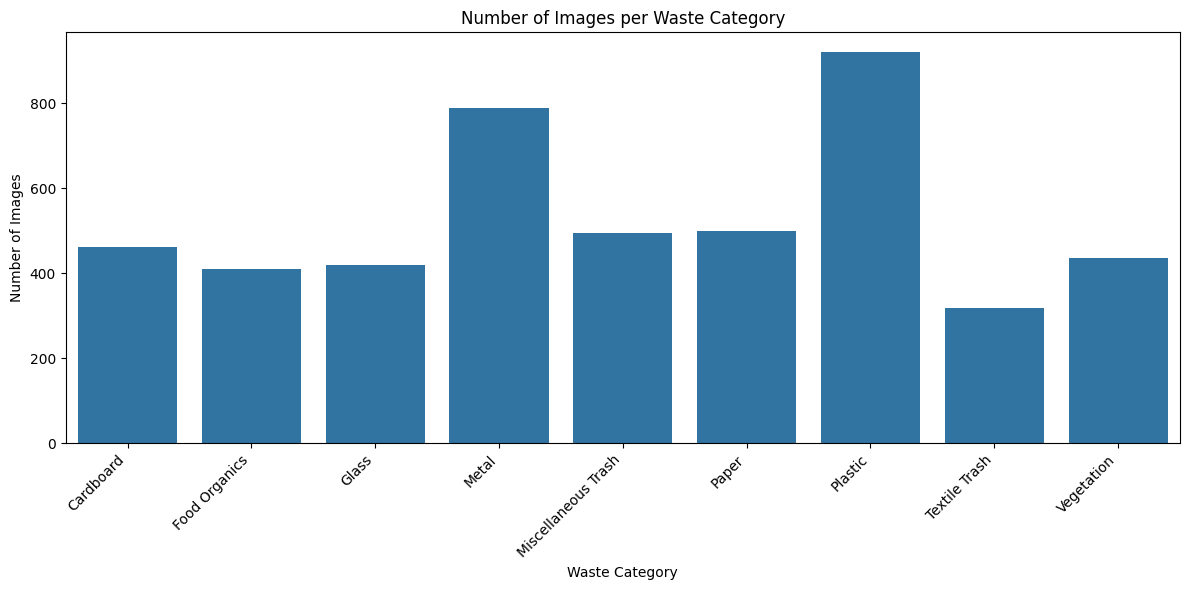

In [10]:

# Visualize the number of images in each category

categories = []
image_counts = []

for category in sorted(os.listdir(data_dir)):
    category_path = data_dir / category

    if category_path.is_dir():
        count = len([
            file for file in category_path.iterdir()
            if file.is_file()
        ])

        categories.append(category)
        image_counts.append(count)

plt.figure(figsize=(12, 6))
sns.barplot(x=categories, y=image_counts)

plt.title("Number of Images per Waste Category")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

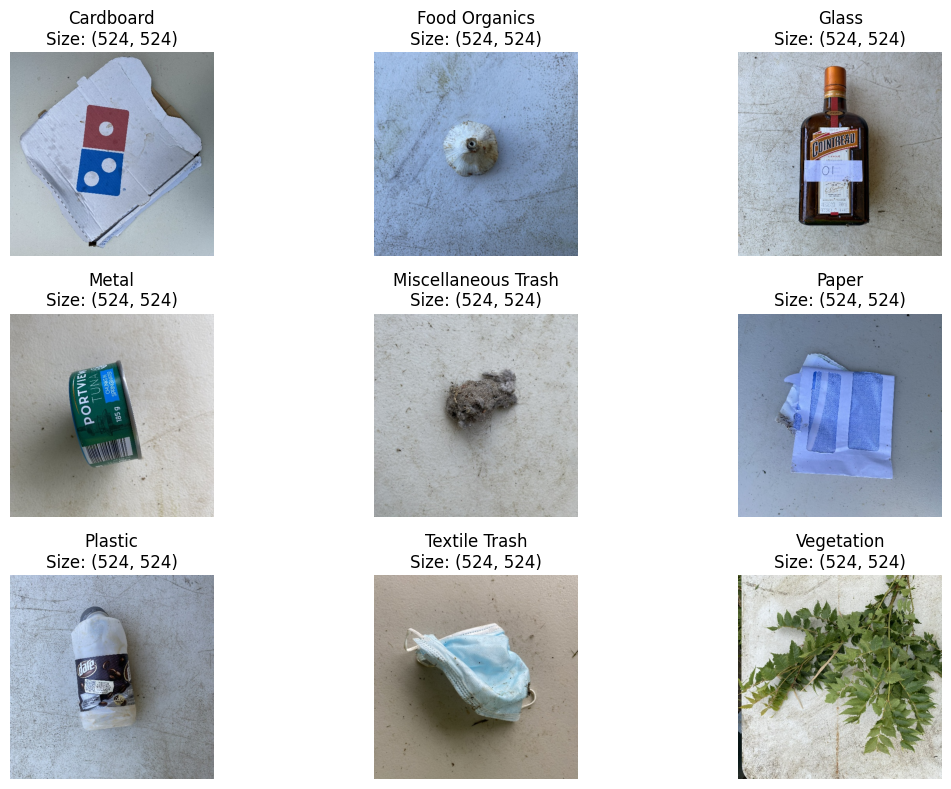

In [11]:
# Exploring image characteristics
categories = sorted([
    folder.name for folder in data_dir.iterdir()
    if folder.is_dir()
])

plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    category_path = data_dir / category

    image_files = [
        file for file in category_path.iterdir()
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    image_path = random.choice(image_files)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"{category}\nSize: {image.size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Image observations
Resolution - All displayed images are 524 × 524 pixels.
Background - Mostly light grey or white surfaces.
Lighting - Lighting and shadows vary slightly between images.
Potential overlap - Some materials may look similar, particularly paper/cardboard so may be hard to seperate

In [12]:
# Double check if all the images have the same dimensions
# Check image dimensions across all categories

image_sizes = []

for category in categories:
    category_path = data_dir / category

    for image_path in category_path.iterdir():
        if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                with Image.open(image_path) as img:
                    image_sizes.append(img.size)

            except Exception as e:
                print(f"Could not read {image_path.name}: {e}")

# Count the different image dimensions
size_counts = pd.Series(image_sizes).value_counts()

print("Number of images checked:", len(image_sizes))
print("\nImage dimensions and their frequencies:")
print(size_counts)

Number of images checked: 4752

Image dimensions and their frequencies:
(524, 524)    4752
Name: count, dtype: int64


All images have a uniform resolution of 524 × 524 pixels.

### 1.2 Explore Text Datasets

TODO: Load and explore the waste description text data
- Load waste_descriptions.csv
- Analyze vocabulary and structure
- Understand the distribution of categories

### Your code here

In [13]:
# Load the waste description dataset

text_data_path = pathlib.Path(
    "/content/drive/MyDrive/WasteManagement/waste_descriptions.csv"
)

text_df = pd.read_csv(text_data_path)

text_df.head()

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


In [14]:
# Examine the structure of the text dataset

print("Dataset shape:", text_df.shape)

print("\nColumn information:")
text_df.info()

print("\nMissing values per column:")
print(text_df.isnull().sum())

Dataset shape: (5000, 5)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB

Missing values per column:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


Number of unique categories: 9

Number of descriptions per category:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


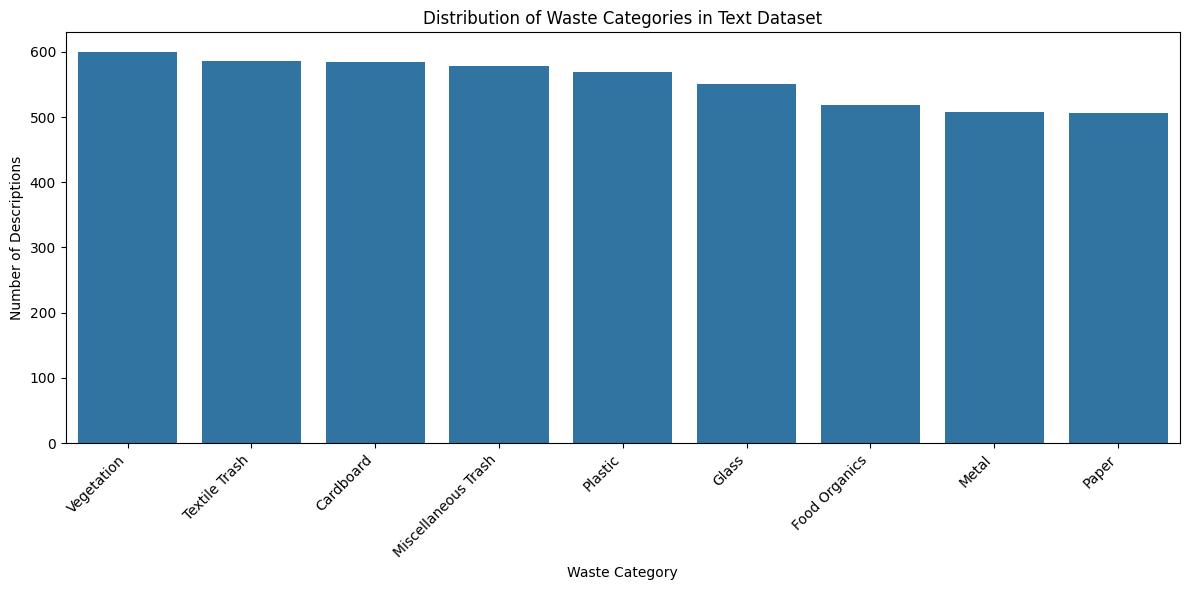

In [15]:
# Analyze the distribution of waste categories

category_counts = text_df['category'].value_counts()

print("Number of unique categories:", text_df['category'].nunique())

print("\nNumber of descriptions per category:")
print(category_counts)

# Visualize category distribution
plt.figure(figsize=(12, 6))

sns.countplot(
    data=text_df,
    x='category',
    order=category_counts.index
)

plt.title("Distribution of Waste Categories in Text Dataset")
plt.xlabel("Waste Category")
plt.ylabel("Number of Descriptions")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The distribution is relatively balanced, with a difference of only 94 descriptions between the largest and smallest categories.

In [16]:
#Explore description length and vocabulary structure

# Analyze the length of waste descriptions

text_df['description_length'] = text_df['description'].apply(
    lambda x: len(str(x).split())
)

print("Description length statistics:")
print(text_df['description_length'].describe())

Description length statistics:
count    5000.000000
mean        4.854000
std         1.549956
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: description_length, dtype: float64


In [17]:
# Analyze the most frequent words in waste descriptions

# Combine all descriptions into one text string
all_descriptions = " ".join(text_df['description'].astype(str))

# Convert text to lowercase and split into individual words
words = all_descriptions.lower().split()

# Count word frequencies
word_counts = Counter(words)

# Display the 20 most frequent words
print("20 Most Frequent Words:")
print(word_counts.most_common(20))

20 Most Frequent Words:
[('with', 727), ('glass', 424), ('empty', 348), ('bottle', 342), ('food', 316), ('paper', 316), ('box', 313), ('residue', 309), ('plastic', 251), ('brand', 247), ('metal', 241), ('dry', 211), ('new', 196), ('soiled', 189), ('crumpled', 189), ('medium', 187), ('orange', 186), ('stained', 185), ('intact', 184), ('broken', 184)]


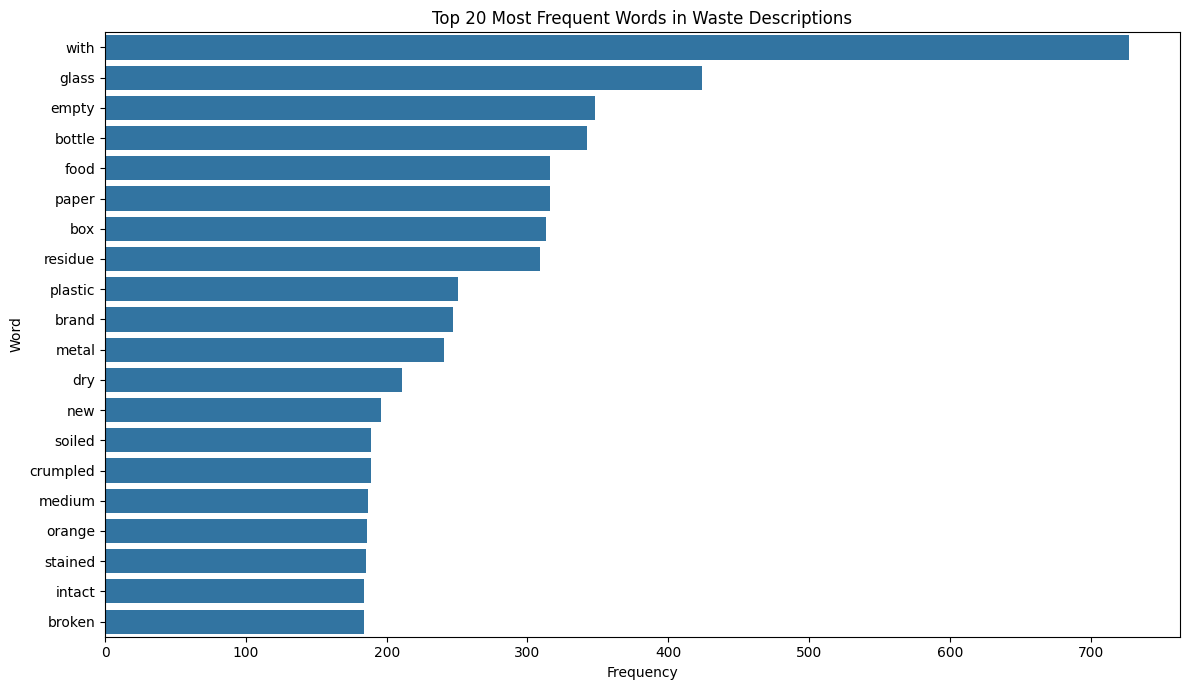

In [18]:
# Visualize the 20 most frequent words

top_words = word_counts.most_common(20)

words_df = pd.DataFrame(
    top_words,
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=words_df,
    x='Frequency',
    y='Word'
)

plt.title("Top 20 Most Frequent Words in Waste Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [19]:
# Display sample descriptions from each waste category

for category in sorted(text_df['category'].unique()):
    print(f"\n--- {category} ---")

    samples = text_df.loc[
        text_df['category'] == category,
        'description'
    ].head(3)

    for description in samples:
        print("-", description)


--- Cardboard ---
- Designer egg carton
- stained red cardboard sleeve with label attached
- new regular-sized purple cardboard tray

--- Food Organics ---
- large Supermarket vegetable waste with food residue
- empty fun-sized purple apple core
- wet compact orange peel with label attached

--- Glass ---
- folded glass bottle leaking
- broken glass container
- clean red wine bottle with food residue

--- Metal ---
- wrinkled metal cutlery with food residue
- partial large purple metal pipe
- used regular-sized striped bottle cap with contents

--- Miscellaneous Trash ---
- gold cigarette butt
- crumpled rubber band
- broken mini Eco-Friendly toy

--- Paper ---
- wrinkled newspaper
- new tissue paper
- clean mini Brand A paper towel

--- Plastic ---
- wrinkled pink takeout container with product remaining
- full black clamshell packaging with food residue
- folded massive yellow milk jug

--- Textile Trash ---
- soiled silver tablecloth
- intact floral carpet piece
- clean small bed s

**Text observations**
- There are 5,000 descriptions and 9 categories. The categories are fairly balanced (506 to 600 each).
- The descriptions are short, about 5 words on average.
- 61 descriptions are duplicates. I remove them before splitting.
- Words like "empty", "dry" and "stained" appear in every category. The item name (bottle, box, t-shirt) is what matters.

### TODO: Load and explore the waste policy documents
### - Load waste_policy_documents.csv
### - Understand document organization and language


In [20]:

# Specify the JSON file path
policy_data_path = pathlib.Path(
    "/content/drive/MyDrive/WasteManagement/waste_policy_documents.json"
)

# Load the JSON data
with open(policy_data_path, "r", encoding="utf-8") as file:
    policy_data = json.load(file)

# Display the data type and a sample
print("Data type:", type(policy_data))
print("\nSample policy data:")
print(policy_data[:2] if isinstance(policy_data, list) else policy_data)

Data type: <class 'list'>

Sample policy data:
[{'policy_id': 1, 'policy_type': 'Textile Trash Recycling Guidelines', 'categories_covered': ['Textile Trash'], 'effective_date': '2023-11-04', 'document_text': 'TEXTILE RECYCLING GUIDELINES\n\nAcceptable Items:\n- Clean clothing (all conditions)\n- Towels, sheets, and linens\n- Fabric scraps\n- Curtains and cloth napkins\n- Handbags and backpacks made of fabric\n- Soft toys and stuffed animals\n\nNon-Acceptable Items:\n- Wet or moldy textiles\n- Heavily soiled items\n- Carpets and rugs\n- Footwear\n- Items with significant non-textile parts\n\nCollection Method:\nPlace items in dedicated textile recycling bins or donate to local thrift stores.\n\nPreparation Instructions:\n- Ensure all items are clean and dry\n- Remove non-textile components when possible\n- Bag similar items together\n\nBenefits:\nTextile recycling conserves resources and reduces landfill waste.', 'jurisdiction': 'Metro City'}, {'policy_id': 2, 'policy_type': 'Glass Recy

In [21]:
# Explore the policy document structure

print("Total policy documents:", len(policy_data))

print("\nAvailable fields:")
print(policy_data[0].keys())

print("\nPolicy types:")

for document in policy_data:
    print("-", document['policy_type'])

Total policy documents: 14

Available fields:
dict_keys(['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction'])

Policy types:
- Textile Trash Recycling Guidelines
- Glass Recycling Guidelines
- Food Organics Recycling Guidelines
- Plastic Recycling Guidelines
- Vegetation Recycling Guidelines
- Cardboard Recycling Guidelines
- Metal Recycling Guidelines
- Paper Recycling Guidelines
- Miscellaneous Trash Recycling Guidelines
- Municipal Waste Guidelines
- Residential Recycling Rules
- Commercial Recycling Standards
- Multi-Unit Building Guidelines
- Community Recycling Program


In [22]:
# Analyze the length of policy documents

for document in policy_data:
    document_text = document['document_text']

    word_count = len(document_text.split())

    print(
        f"{document['policy_type']}: "
        f"{word_count} words"
    )

Textile Trash Recycling Guidelines: 104 words
Glass Recycling Guidelines: 86 words
Food Organics Recycling Guidelines: 98 words
Plastic Recycling Guidelines: 94 words
Vegetation Recycling Guidelines: 94 words
Cardboard Recycling Guidelines: 87 words
Metal Recycling Guidelines: 102 words
Paper Recycling Guidelines: 95 words
Miscellaneous Trash Recycling Guidelines: 97 words
Municipal Waste Guidelines: 100 words
Residential Recycling Rules: 146 words
Commercial Recycling Standards: 102 words
Multi-Unit Building Guidelines: 100 words
Community Recycling Program: 120 words


In [23]:
#Examine the language and organization of a policy
# Display one complete policy document

sample_policy = policy_data[0]

print("Policy:", sample_policy['policy_type'])
print("Jurisdiction:", sample_policy['jurisdiction'])
print("Effective date:", sample_policy['effective_date'])

print("\nDocument content:\n")
print(sample_policy['document_text'])

Policy: Textile Trash Recycling Guidelines
Jurisdiction: Metro City
Effective date: 2023-11-04

Document content:

TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled items
- Carpets and rugs
- Footwear
- Items with significant non-textile parts

Collection Method:
Place items in dedicated textile recycling bins or donate to local thrift stores.

Preparation Instructions:
- Ensure all items are clean and dry
- Remove non-textile components when possible
- Bag similar items together

Benefits:
Textile recycling conserves resources and reduces landfill waste.


In [24]:
# Examine the waste categories covered by each policy

for document in policy_data:
    print(f"\nPolicy: {document['policy_type']}")
    print("Categories covered:", document['categories_covered'])


Policy: Textile Trash Recycling Guidelines
Categories covered: ['Textile Trash']

Policy: Glass Recycling Guidelines
Categories covered: ['Glass']

Policy: Food Organics Recycling Guidelines
Categories covered: ['Food Organics']

Policy: Plastic Recycling Guidelines
Categories covered: ['Plastic']

Policy: Vegetation Recycling Guidelines
Categories covered: ['Vegetation']

Policy: Cardboard Recycling Guidelines
Categories covered: ['Cardboard']

Policy: Metal Recycling Guidelines
Categories covered: ['Metal']

Policy: Paper Recycling Guidelines
Categories covered: ['Paper']

Policy: Miscellaneous Trash Recycling Guidelines
Categories covered: ['Miscellaneous Trash']

Policy: Municipal Waste Guidelines
Categories covered: ['Plastic', 'Miscellaneous Trash', 'Vegetation']

Policy: Residential Recycling Rules
Categories covered: ['Plastic', 'Metal', 'Glass', 'Miscellaneous Trash', 'Vegetation']

Policy: Commercial Recycling Standards
Categories covered: ['Food Organics', 'Metal', 'Miscell

Policy observations

Policies 1 to 9 each cover one category. Policies 10 to 14 cover several categories in a shorter form, so some information is repeated.
Every single-category policy has the same sections (Acceptable Items, Non-Acceptable Items, Collection Method, Preparation Instructions, Benefits).
The policies disagree on window glass: policy 2 says it is not acceptable, but policies 11 and 13 list it with glass. I show the source of each answer for this reason.

### 1.3 Create Data Pipelines

In [25]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path
import pathlib
data_dir = pathlib.Path('/content/drive/MyDrive/WasteManagement/RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


TODO: Create a text preprocessing pipeline
- Tokenization
- Text cleaning
- Split data into train and test
- Create embeddings/features


In [27]:

# 1. Select input features and target
X = text_df['description'].copy()
y = text_df['category'].copy()


# 2. Text cleaning
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


X = X.apply(clean_text)


# 3. Tokenization
# Split each description into individual words
X_tokens = X.apply(lambda text: text.split())

print("Original description:")
print(text_df['description'].iloc[0])

print("\nCleaned description:")
print(X.iloc[0])

print("\nTokenized description:")
print(X_tokens.iloc[0])


# 4. Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# 6. Convert text into numerical features using TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)


# 7. Display pipeline results
print("\n========== PIPELINE RESULTS ==========")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

print("\nEncoded categories:")
print(label_encoder.classes_)

print("\nSample TF-IDF features:")
print(tfidf_vectorizer.get_feature_names_out()[:20])

Original description:
soiled silver tablecloth

Cleaned description:
soiled silver tablecloth

Tokenized description:
['soiled', 'silver', 'tablecloth']

========== PIPELINE RESULTS ==========
Training samples: 4000
Testing samples: 1000
Training feature shape: (4000, 5000)
Testing feature shape: (1000, 5000)

Encoded categories:
['Cardboard' 'Food Organics' 'Glass' 'Metal' 'Miscellaneous Trash' 'Paper'
 'Plastic' 'Textile Trash' 'Vegetation']

Sample TF-IDF features:
['aerosol' 'aerosol can' 'aluminum' 'aluminum can' 'aluminum foil' 'apple'
 'apple core' 'appliance' 'appliance box' 'artisanal' 'artisanal battery'
 'artisanal branches' 'artisanal bread' 'artisanal bush'
 'artisanal cardboard' 'artisanal carpet' 'artisanal cddvd'
 'artisanal chicken' 'artisanal cigarette' 'artisanal clamshell']


In [28]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

TODO: Prepare documents for RAG
- Document preprocessing
- Create embeddings for retrieval



In [29]:
# Inspect one complete policy document

sample_policy = policy_data[0]

print("Policy:", sample_policy['policy_type'])
print("Jurisdiction:", sample_policy['jurisdiction'])
print("Effective date:", sample_policy['effective_date'])
print("Categories:", sample_policy['categories_covered'])

print("\nDocument text:\n")
print(sample_policy['document_text'])

Policy: Textile Trash Recycling Guidelines
Jurisdiction: Metro City
Effective date: 2023-11-04
Categories: ['Textile Trash']

Document text:

TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled items
- Carpets and rugs
- Footwear
- Items with significant non-textile parts

Collection Method:
Place items in dedicated textile recycling bins or donate to local thrift stores.

Preparation Instructions:
- Ensure all items are clean and dry
- Remove non-textile components when possible
- Bag similar items together

Benefits:
Textile recycling conserves resources and reduces landfill waste.


In [30]:
#RAG document processing and chunking

# Function to clean document text
def clean_document(text):
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


#  Function to split documents into chunks
def split_into_chunks(text, chunk_size=150, overlap=30):

    words = text.split()
    chunks = []

    start = 0

    while start < len(words):
        end = start + chunk_size

        chunk = " ".join(words[start:end])
        chunks.append(chunk)

        start += chunk_size - overlap

    return chunks


# Prepare policy documents
rag_documents = []

for document in policy_data:

    # Combine policy metadata and document text
    combined_text = f"""
    Policy: {document['policy_type']}
    Jurisdiction: {document['jurisdiction']}
    Effective Date: {document['effective_date']}
    Categories: {', '.join(document['categories_covered'])}

    {document['document_text']}
    """

    # Clean document
    cleaned_text = clean_document(combined_text)

    # Split into chunks
    chunks = split_into_chunks(cleaned_text)

    # Store each chunk with its metadata
    for i, chunk in enumerate(chunks):

        rag_documents.append({
            'chunk_id': f"{document['policy_id']}_chunk_{i}",
            'policy_type': document['policy_type'],
            'jurisdiction': document['jurisdiction'],
            'categories': document['categories_covered'],
            'text': chunk
        })


# Inspect results
print("Total policy documents:", len(policy_data))
print("Total document chunks:", len(rag_documents))

print("\nSample chunk:")
print(rag_documents[0]['text'])

print("\nSample metadata:")
print({
    key: value
    for key, value in rag_documents[0].items()
    if key != 'text'
})

Total policy documents: 14
Total document chunks: 16

Sample chunk:
Policy: Textile Trash Recycling Guidelines Jurisdiction: Metro City Effective Date: 2023-11-04 Categories: Textile Trash TEXTILE RECYCLING GUIDELINES Acceptable Items: - Clean clothing (all conditions) - Towels, sheets, and linens - Fabric scraps - Curtains and cloth napkins - Handbags and backpacks made of fabric - Soft toys and stuffed animals Non-Acceptable Items: - Wet or moldy textiles - Heavily soiled items - Carpets and rugs - Footwear - Items with significant non-textile parts Collection Method: Place items in dedicated textile recycling bins or donate to local thrift stores. Preparation Instructions: - Ensure all items are clean and dry - Remove non-textile components when possible - Bag similar items together Benefits: Textile recycling conserves resources and reduces landfill waste.

Sample metadata:
{'chunk_id': '1_chunk_0', 'policy_type': 'Textile Trash Recycling Guidelines', 'jurisdiction': 'Metro City', 

In [31]:

!pip -q install sentence-transformers

In [32]:
print("Sentence Transformers version:", sentence_transformers.__version__)


Sentence Transformers version: 5.7.0


In [33]:
#Load the embedding model and generate embeddin

# Load pretrained embedding model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

#  Extract text from policy chunks
chunk_texts = [doc['text'] for doc in rag_documents]

#  Generate embeddings
document_embeddings = embedding_model.encode(
    chunk_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

# Inspect embeddings
print("Number of document chunks:", len(chunk_texts))
print("Embedding shape:", document_embeddings.shape)
print("First embedding (first 10 values):")
print(document_embeddings[0][:10])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Number of document chunks: 16
Embedding shape: (16, 384)
First embedding (first 10 values):
[-0.06384782  0.06413313  0.03941711 -0.01767199  0.0515892   0.03161148
  0.05318858 -0.04363596 -0.10674426  0.04246897]


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [34]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

In [35]:

# IMAGE PREPROCESSING FOR CNN


# Create a normalization layer
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply normalization to each dataset
train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

validation_ds = validation_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

# Prefetch for improved performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Image preprocessing completed!")

Image preprocessing completed!


In [36]:
# Get one batch from the training dataset
for images, labels in train_ds.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32, 9)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### 2.2 Implement CNN Model with Transfer Learning

In [37]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

In [38]:


# 1. Determine number of classes
num_classes = len(class_names)

# 2. Load pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 3. Freeze pretrained layers
base_model.trainable = False

# 4. Build custom classification head
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Convert pixel values from [0, 1] to [-1, 1]
x = tf.keras.layers.Rescaling(
    scale=2.0,
    offset=-1.0
)(inputs)

# Extract features using MobileNetV2
x = base_model(x, training=False)

# Reduce spatial dimensions
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Apply dropout to reduce overfitting
x = tf.keras.layers.Dropout(0.2)(x)

# Classify into 9 waste categories
outputs = tf.keras.layers.Dense(
    num_classes,
    activation='softmax'
)(x)

# 5. Create final model
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

# 6. Configure loss function and metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Display model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.3 Train and Evaluate the Model

In [39]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [40]:

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 107s 596ms/step - accuracy: 0.5413 - loss: 1.2807 - val_accuracy: 0.6936 - val_loss: 0.8415
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7409 - loss: 0.7410 - val_accuracy: 0.7489 - val_loss: 0.6931
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7872 - loss: 0.6103 - val_accuracy: 0.7702 - val_loss: 0.6583
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8048 - loss: 0.5433 - val_accuracy: 0.7809 - val_loss: 0.6150
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8372 - loss: 0.4708 - val_accuracy: 0.7979 - val_loss: 0.5952
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8446 - loss: 0.4416 - val_accuracy: 0.8149 - val_loss: 0.5789
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8617 - loss: 0.4001 - val_accuracy: 0.8064 - val_loss: 0.5783
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8809 - loss: 0.3676 - val_a

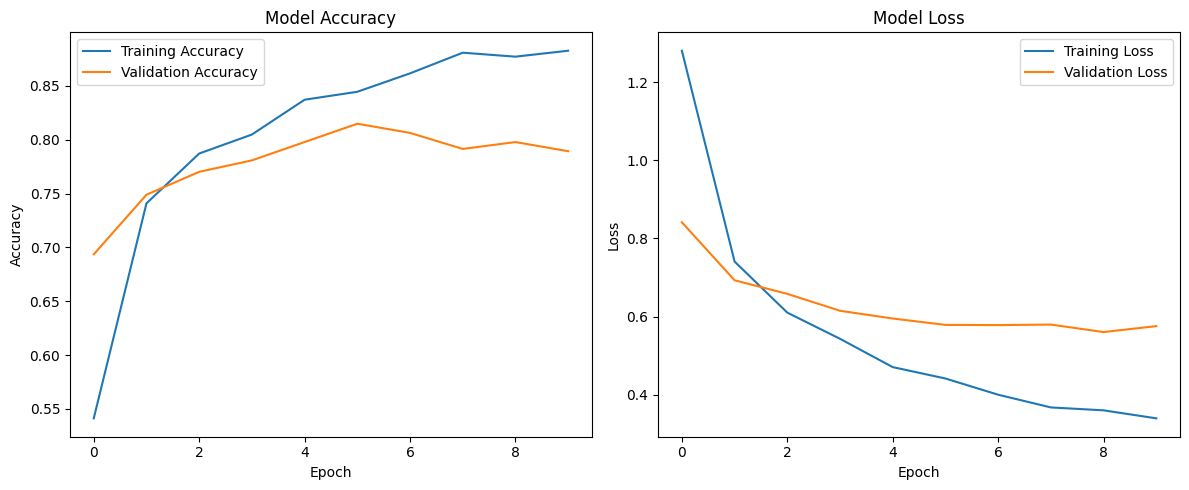

In [41]:

#Visulaize
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

In [43]:
# Evaluate model performance on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions
y_pred_prob = model.predict(test_dataset)

# Convert probabilities into predicted class indices
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions shape:", y_pred.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.8083 - loss: 0.5498
Test Loss: 0.5498
Test Accuracy: 0.8083
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
Predictions shape: (480,)


In [44]:
# Extract the true labels from the test dataset
y_true = np.concatenate([
    labels.numpy() for images, labels in test_dataset
])

# Convert one-hot encoded labels to class indices
y_true = np.argmax(y_true, axis=1)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

True labels shape: (480,)
Predicted labels shape: (480,)


In [45]:
# Collect predictions and actual labels in the same pass
y_true_batches = []
y_pred_batches = []

for images, labels in test_dataset:
    # Get model predictions
    predictions = model(images, training=False)

    # Store actual and predicted class indices
    y_true_batches.append(np.argmax(labels.numpy(), axis=1))
    y_pred_batches.append(np.argmax(predictions.numpy(), axis=1))

# Combine batches
y_true = np.concatenate(y_true_batches)
y_pred = np.concatenate(y_pred_batches)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

True labels shape: (480,)
Predicted labels shape: (480,)


<Figure size 1200x1000 with 0 Axes>

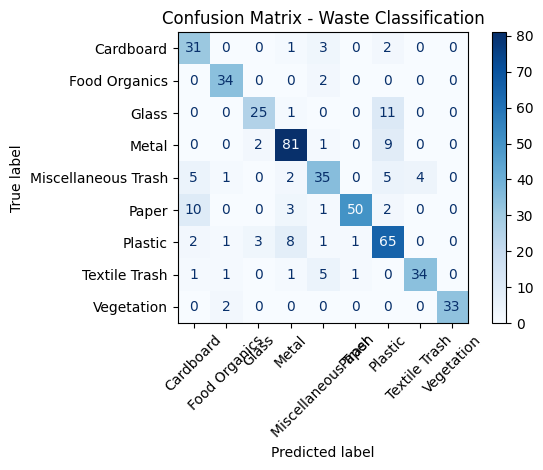

In [46]:


# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='Blues',
    xticks_rotation=45,
    values_format='d'
)

plt.title('Confusion Matrix - Waste Classification')
plt.tight_layout()
plt.show()

The model incorrectly classified 11 Glass images as Plastic.Also the model classified 10 Paper images as Cardboard. There are other misclassications too.

Total misclassified images: 92


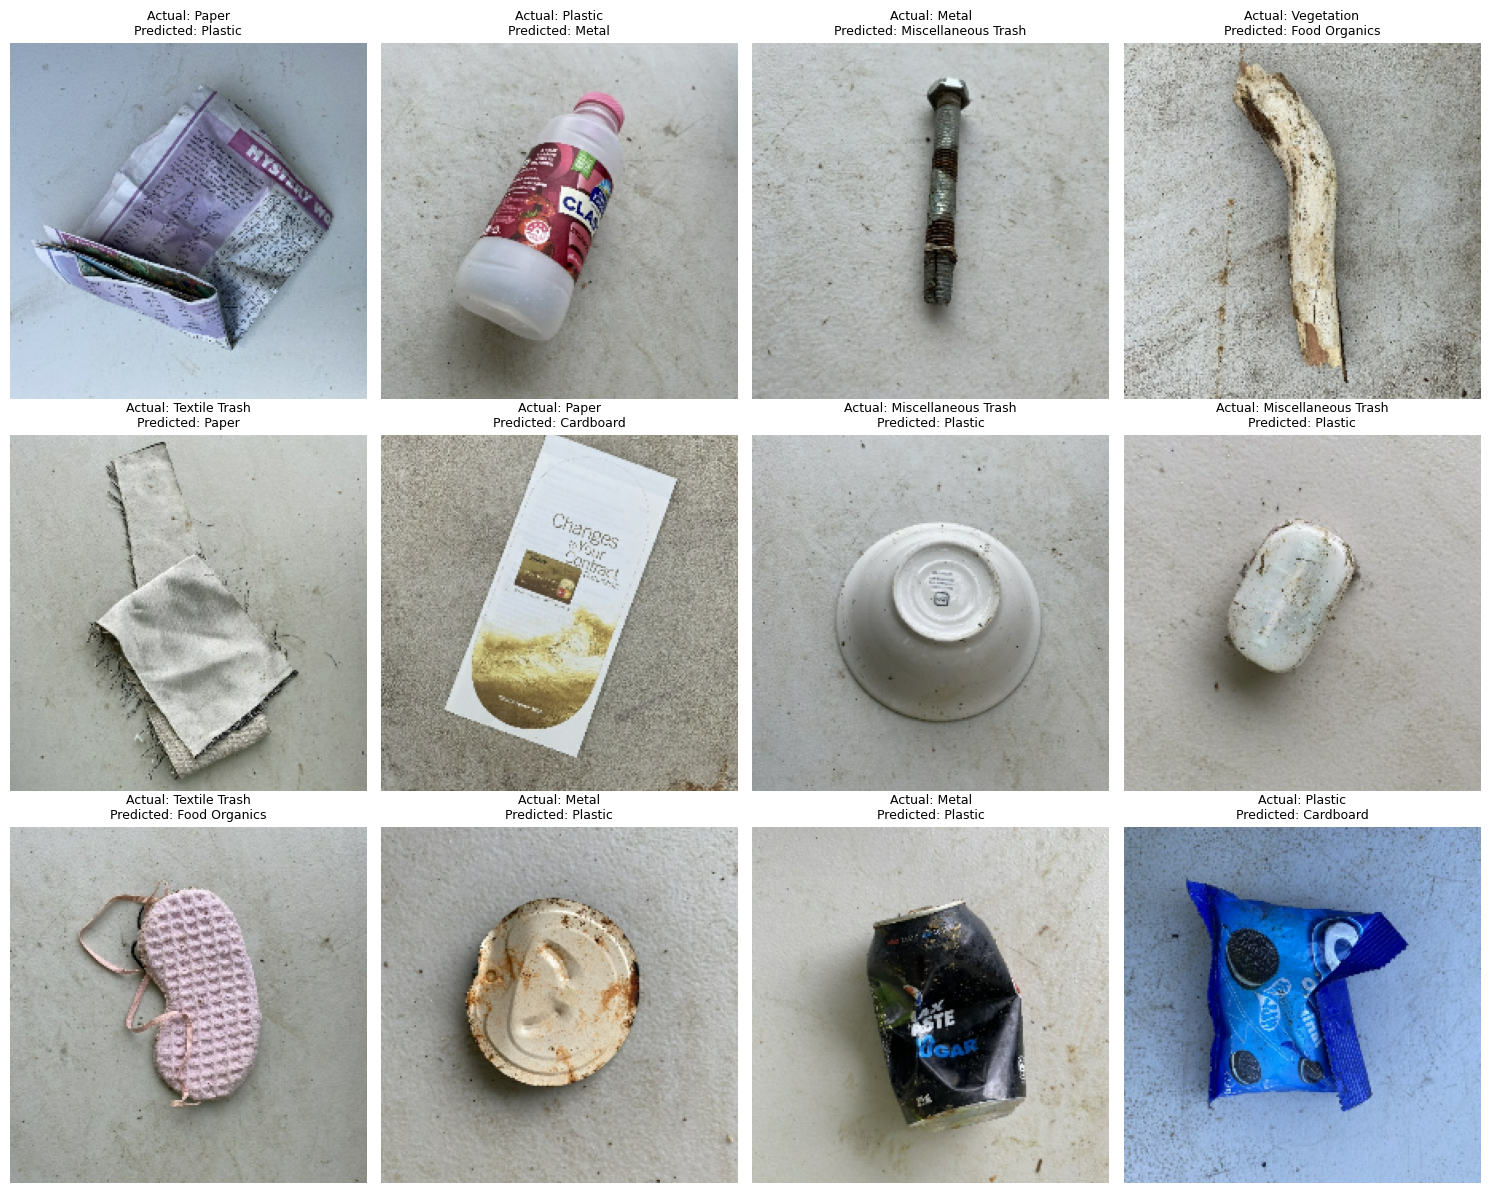

In [47]:
# Collect test images, true labels and predictions
test_images = []
y_true_batches = []
y_pred_batches = []

for images, labels in test_dataset:
    predictions = model(images, training=False)

    test_images.append(images.numpy())
    y_true_batches.append(np.argmax(labels.numpy(), axis=1))
    y_pred_batches.append(np.argmax(predictions.numpy(), axis=1))

# Combine batches
test_images = np.concatenate(test_images)
y_true = np.concatenate(y_true_batches)
y_pred = np.concatenate(y_pred_batches)

# Find misclassified images
misclassified_indices = np.where(y_true != y_pred)[0]

print("Total misclassified images:", len(misclassified_indices))

# Select 12 examples
sample_indices = misclassified_indices[:12]

# Plot the misclassified images
plt.figure(figsize=(15, 12))

for i, idx in enumerate(sample_indices):
    plt.subplot(3, 4, i + 1)

    plt.imshow(test_images[idx])

    actual_label = class_names[y_true[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}",
        fontsize=9
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

Comment:

The classes misclassified the most are plastics, textile trash and metal
This is possibly due to similar looking materials, and fewer images to train them on.

### 2.4 Fine-tune the Model

In [48]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

In [49]:

# Number of waste categories
num_classes = len(class_names)

# Load pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Initially freeze the pretrained base
base_model.trainable = False

# Build classification model
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Scale pixel values from [0, 1] to [-1, 1]
x = tf.keras.layers.Rescaling(
    scale=2.0,
    offset=-1.0
)(inputs)

# Extract image features
x = base_model(x, training=False)

# Reduce spatial dimensions
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Add regularized dense layer
x = tf.keras.layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.001)
)(x)

# Apply dropout
x = tf.keras.layers.Dropout(0.4)(x)

# Classification output
outputs = tf.keras.layers.Dense(
    num_classes,
    activation='softmax'
)(x)

# Create final model
final_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

# Compile
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

final_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [50]:


# Save the best model based on validation loss
checkpoint = ModelCheckpoint(
    'best_waste_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Stop training if validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    mode='min'
)

history_initial = final_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2919 - loss: 2.4704
Epoch 1: val_loss improved from None to 1.55903, saving model to best_waste_model.keras

Epoch 1: finished saving model to best_waste_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 177ms/step - accuracy: 0.3977 - loss: 2.1585 - val_accuracy: 0.6362 - val_loss: 1.5590
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6036 - loss: 1.6028
Epoch 2: val_loss improved from 1.55903 to 1.28905, saving model to best_waste_model.keras

Epoch 2: finished saving model to best_waste_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6157 - loss: 1.5453 - val_accuracy: 0.7000 - val_loss: 1.2890
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6859 - loss: 1.3483
Epoch 3: val_loss improved from 1.28905 to 1.17282, saving model to best_waste_model.keras

Epoch 3: finished saving model to best_waste_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6

In [51]:
# Access the MobileNetV2 base model
base_model = final_model.get_layer('mobilenetv2_1.00_224')

# Make the base model trainable
base_model.trainable = True

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last 20 layers,
# keeping BatchNormalization layers frozen
for layer in base_model.layers[-20:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Count trainable layers
trainable_layers = sum(
    layer.trainable for layer in base_model.layers
)

print("Trainable MobileNetV2 layers:", trainable_layers)

Trainable MobileNetV2 layers: 13


In [52]:
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
history_finetune = final_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8644 - loss: 0.7986
Epoch 1: val_loss improved from 0.94707 to 0.91778, saving model to best_waste_model.keras

Epoch 1: finished saving model to best_waste_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 43s 253ms/step - accuracy: 0.8680 - loss: 0.7812 - val_accuracy: 0.8149 - val_loss: 0.9178
Epoch 2/10
118/119 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8648 - loss: 0.7414
Epoch 2: val_loss improved from 0.91778 to 0.90028, saving model to best_waste_model.keras

Epoch 2: finished saving model to best_waste_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8780 - loss: 0.7331 - val_accuracy: 0.8191 - val_loss: 0.9003
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8945 - loss: 0.6936
Epoch 3: val_loss improved from 0.90028 to 0.88874, saving model to best_waste_model.keras

Epoch 3: finished saving model to best_waste_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy:

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [54]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

In [55]:

X_text = X.copy()
y_text = y_encoded.copy()


X_text_tfidf = tfidf_vectorizer.transform(X_text)

print("Text features shape:", X_text_tfidf.shape)
print("Target shape:", y_text.shape)
print("Number of waste categories:", len(label_encoder.classes_))
print("\nWaste categories:")
print(label_encoder.classes_)

Text features shape: (5000, 5000)
Target shape: (5000,)
Number of waste categories: 9

Waste categories:
['Cardboard' 'Food Organics' 'Glass' 'Metal' 'Miscellaneous Trash' 'Paper'
 'Plastic' 'Textile Trash' 'Vegetation']


In [56]:

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text_tfidf,
    y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text
)

print("Training features:", X_train_text.shape)
print("Testing features:", X_test_text.shape)

print("Training labels:", y_train_text.shape)
print("Testing labels:", y_test_text.shape)

Training features: (4000, 5000)
Testing features: (1000, 5000)
Training labels: (4000,)
Testing labels: (1000,)


### 3.2 Implement Text Classification Model

In [57]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

I chose **Option A (traditional ML)**. The descriptions are short, so TF-IDF with Naive Bayes should work well and is fast to train. I also try Logistic Regression to compare.

In [58]:


nb_model = MultinomialNB()


nb_model.fit(X_train_text, y_train_text)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


### 3.3 Train and Evaluate the Model

In [59]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [60]:


# Predictions on training data
y_train_pred = nb_model.predict(X_train_text)

# Predictions on testing data
y_test_pred = nb_model.predict(X_test_text)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_text, y_train_pred)
test_accuracy = accuracy_score(y_test_text, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Accuracy Difference: {train_accuracy - test_accuracy:.4f}")

Training Accuracy: 0.9998
Testing Accuracy: 0.9960
Accuracy Difference: 0.0038


In [61]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

In [62]:

# classification report
print(classification_report(
    y_test_text,
    y_test_pred,
    target_names=label_encoder.classes_
))

                     precision    recall  f1-score   support

          Cardboard       0.99      1.00      1.00       117
      Food Organics       1.00      1.00      1.00       104
              Glass       1.00      1.00      1.00       110
              Metal       1.00      1.00      1.00       101
Miscellaneous Trash       1.00      0.97      0.98       116
              Paper       1.00      1.00      1.00       101
            Plastic       0.98      1.00      0.99       114
      Textile Trash       0.99      1.00      1.00       117
         Vegetation       1.00      1.00      1.00       120

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



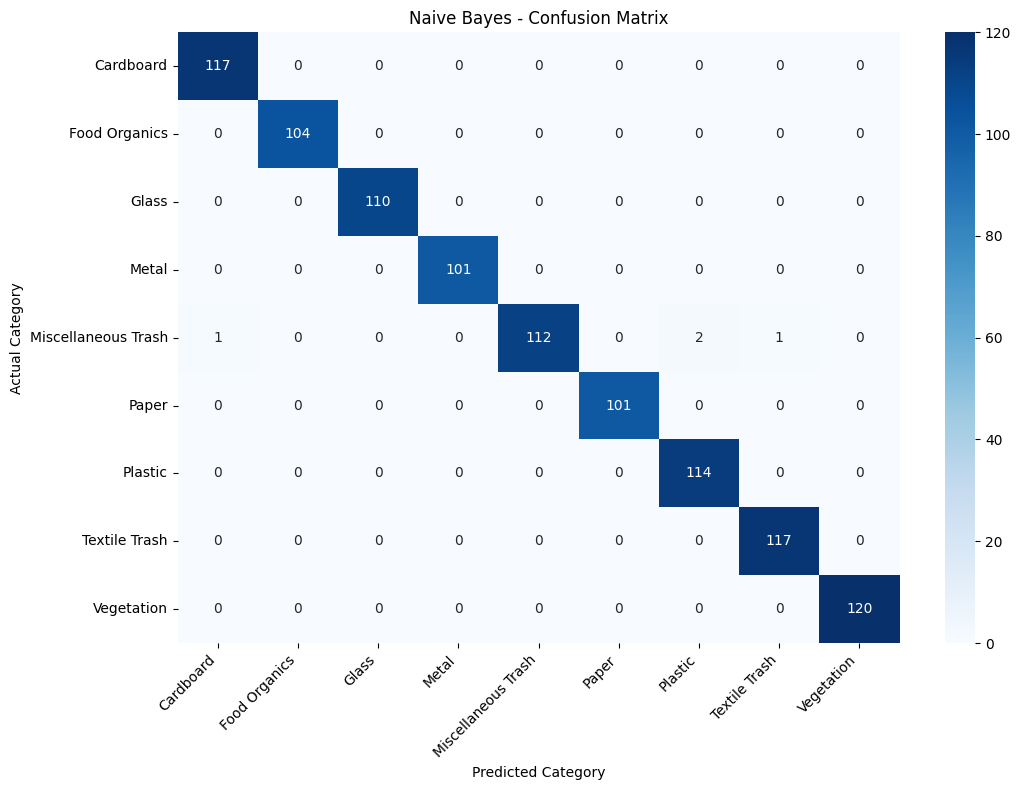

In [63]:
# confusion matrix
cm = confusion_matrix(y_test_text, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(11, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
#Analyze error patterns
errors = y_test_text != y_test_pred

print("\nError Analysis:")
print(f"Total test samples: {len(y_test_text)}")
print(f"Correct predictions: {(~errors).sum()}")
print(f"Incorrect predictions: {errors.sum()}")

# Identify the categories involved in misclassification
if errors.sum() > 0:
    error_df = pd.DataFrame({
        'Actual Category': label_encoder.inverse_transform(y_test_text[errors]),
        'Predicted Category': label_encoder.inverse_transform(y_test_pred[errors])
    })

    print("\nMisclassification patterns:")
    print(
        error_df.groupby(
            ['Actual Category', 'Predicted Category']
        ).size().reset_index(name='Count')
    )


Error Analysis:
Total test samples: 1000
Correct predictions: 996
Incorrect predictions: 4

Misclassification patterns:
       Actual Category Predicted Category  Count
0  Miscellaneous Trash          Cardboard      1
1  Miscellaneous Trash            Plastic      2
2  Miscellaneous Trash      Textile Trash      1


In [65]:
#Save the model


# Save trained Naive Bayes model
joblib.dump(nb_model, 'naive_bayes_waste_model.pkl')

# Save fitted TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

# Save label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')

print("Model, vectorizer, and label encoder saved successfully!")

Model, vectorizer, and label encoder saved successfully!


### 3.4 Create Classification Function

In [66]:
# TODO: Create a function that takes a text description and returns the predicted waste category
def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """

    # Check that the input is a valid string
    if not isinstance(description, str) or not description.strip():
        raise ValueError("Please provide a valid waste description.")

    #  Clean the description
    cleaned_description = clean_text(description)

    # Convert the description into TF-IDF features
    description_tfidf = tfidf_vectorizer.transform([cleaned_description])

    # Predict the numerical category
    prediction = nb_model.predict(description_tfidf)

    #  Convert numerical prediction into category name
    predicted_category = label_encoder.inverse_transform(prediction)[0]

    return predicted_category

In [67]:
# Test descriptions
test_descriptions = [
    "An empty plastic water bottle",
    "Used cardboard packaging box",
    "Rotten banana peels and vegetable leftovers",
    "Broken glass drinking bottle",
    "Old metal food cans"
]

# Classify each description
for description in test_descriptions:
    category = classify_waste_description(description)

    print(f"Description: {description}")
    print(f"Predicted category: {category}")
    print("-" * 50)

Description: An empty plastic water bottle
Predicted category: Plastic
--------------------------------------------------
Description: Used cardboard packaging box
Predicted category: Cardboard
--------------------------------------------------
Description: Rotten banana peels and vegetable leftovers
Predicted category: Food Organics
--------------------------------------------------
Description: Broken glass drinking bottle
Predicted category: Glass
--------------------------------------------------
Description: Old metal food cans
Predicted category: Textile Trash
--------------------------------------------------


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [68]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

In [69]:
# Check the prepared RAG documents and embeddings

print("Number of RAG document chunks:", len(rag_documents))

print("Document embedding shape:", document_embeddings.shape)

print("\nSample RAG document:")
print(rag_documents[0])

print("\nEmbedding model:", embedding_model)

Number of RAG document chunks: 16
Document embedding shape: (16, 384)

Sample RAG document:
{'chunk_id': '1_chunk_0', 'policy_type': 'Textile Trash Recycling Guidelines', 'jurisdiction': 'Metro City', 'categories': ['Textile Trash'], 'text': 'Policy: Textile Trash Recycling Guidelines Jurisdiction: Metro City Effective Date: 2023-11-04 Categories: Textile Trash TEXTILE RECYCLING GUIDELINES Acceptable Items: - Clean clothing (all conditions) - Towels, sheets, and linens - Fabric scraps - Curtains and cloth napkins - Handbags and backpacks made of fabric - Soft toys and stuffed animals Non-Acceptable Items: - Wet or moldy textiles - Heavily soiled items - Carpets and rugs - Footwear - Items with significant non-textile parts Collection Method: Place items in dedicated textile recycling bins or donate to local thrift stores. Preparation Instructions: - Ensure all items are clean and dry - Remove non-textile components when possible - Bag similar items together Benefits: Textile recycling 

In [70]:
# Select relevant disposal instruction columns
disposal_df = text_df[
    ['category', 'disposal_instruction']
].copy()


disposal_df = disposal_df.dropna(
    subset=['category', 'disposal_instruction']
)

disposal_df = disposal_df.drop_duplicates()


disposal_documents = []

for idx, row in disposal_df.iterrows():

    document = {
        'chunk_id': f'disposal_{idx}',
        'policy_type': 'Disposal Instructions',
        'jurisdiction': 'General',
        'categories': [row['category']],
        'text': f"""
        Waste Category: {row['category']}
        Disposal Instructions: {row['disposal_instruction']}
        """
    }

    disposal_documents.append(document)

print("Number of disposal instruction documents:", len(disposal_documents))

print("\nSample disposal document:")
print(disposal_documents[0])

Number of disposal instruction documents: 45

Sample disposal document:
{'chunk_id': 'disposal_0', 'policy_type': 'Disposal Instructions', 'jurisdiction': 'General', 'categories': ['Textile Trash'], 'text': '\n        Waste Category: Textile Trash\n        Disposal Instructions: Look for textile recycling programs in your area.\n        '}


In [71]:
# Combine policy chunks and disposal instruction documents
all_rag_documents = rag_documents + disposal_documents

print("Total RAG documents:", len(all_rag_documents))
print("\nPolicy documents:", len(rag_documents))
print("Disposal instruction documents:", len(disposal_documents))

# Inspect one document from each source
print("\nPolicy document:")
print(rag_documents[0])

print("\nDisposal instruction document:")
print(disposal_documents[0])

Total RAG documents: 61

Policy documents: 16
Disposal instruction documents: 45

Policy document:
{'chunk_id': '1_chunk_0', 'policy_type': 'Textile Trash Recycling Guidelines', 'jurisdiction': 'Metro City', 'categories': ['Textile Trash'], 'text': 'Policy: Textile Trash Recycling Guidelines Jurisdiction: Metro City Effective Date: 2023-11-04 Categories: Textile Trash TEXTILE RECYCLING GUIDELINES Acceptable Items: - Clean clothing (all conditions) - Towels, sheets, and linens - Fabric scraps - Curtains and cloth napkins - Handbags and backpacks made of fabric - Soft toys and stuffed animals Non-Acceptable Items: - Wet or moldy textiles - Heavily soiled items - Carpets and rugs - Footwear - Items with significant non-textile parts Collection Method: Place items in dedicated textile recycling bins or donate to local thrift stores. Preparation Instructions: - Ensure all items are clean and dry - Remove non-textile components when possible - Bag similar items together Benefits: Textile rec

In [72]:
# Extract text from all RAG documents
all_document_texts = [
    document['text'] for document in all_rag_documents
]

# Generate embeddings
all_document_embeddings = embedding_model.encode(
    all_document_texts,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Number of documents:", len(all_rag_documents))
print("Embedding shape:", all_document_embeddings.shape)

Number of documents: 61
Embedding shape: (61, 384)


### 4.2 Implement RAG-based System

In [73]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

In [89]:

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

llm = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    dtype=torch.float32
).to("cuda")

print("Model loaded:", next(llm.parameters()).device)
print("Model data type:", next(llm.parameters()).dtype)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded: cuda:0
Model data type: torch.float32


In [90]:

def retrieve_documents(query, top_k=3):

    # Generate an embedding for the user's query
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # Calculate cosine similarity
    similarities = cosine_similarity(
        query_embedding,
        all_document_embeddings
    )[0]

    # Identify the most relevant documents
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []

    for idx in top_indices:
        results.append({
            'document': all_rag_documents[idx],
            'similarity': similarities[idx]
        })

    return results

print("Retrieval function defined successfully!")

Retrieval function defined successfully!


In [91]:
def retrieve_policy_context(category, query, top_k=3):

    # Combine the category and user's question
    search_query = f"{category}: {query}"

    # Retrieve relevant documents
    retrieved_results = retrieve_documents(
        search_query,
        top_k=top_k
    )

    # Extract the document text
    context = "\n\n".join([
        result['document']['text']
        for result in retrieved_results
    ])

    return context, retrieved_results


# Test the retrieval function
context, retrieved_results = retrieve_policy_context(
    category="Plastic",
    query="How should I prepare plastic bottles for recycling?"
)

print("Retrieved documents:", len(retrieved_results))
print("\nRetrieved policy context:\n")
print(context)

Retrieved documents: 3

Retrieved policy context:

Policy: Plastic Recycling Guidelines Jurisdiction: Metro City Effective Date: 2023-04-05 Categories: Plastic PLASTIC RECYCLING GUIDELINES Acceptable Items: - PET bottles and containers (code #1) - HDPE containers (code #2) - PP containers (code #5) - Clean plastic packaging Non-Acceptable Items: - Plastic bags and film - Polystyrene foam (code #6) - Containers with food residue - Mixed material packaging - Black plastic containers Collection Method: Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted. Preparation Instructions: - Rinse containers - Remove lids and caps (recycle separately) - Check for recycling codes (1-7) Benefits: Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

Policy: Glass Recycling Guidelines Jurisdiction: Metro City Effective Date: 2023-01-24 Categories: Glass GLASS RECYCLING GUIDELINES Acceptable Items: - Glass bottles (all colors) - Glass j

### 4.3 Adjust and Evaluate the System

In [77]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [113]:
question_templates = [
    "How should I dispose of or recycle {}?",
    "What is the correct way to handle {} waste?",
    "How can I prepare {} for disposal?",
    "What are the recycling guidelines for {}?",
    "Where should {} waste be placed?"
]

training_examples = []

for category, target in improved_targets.items():

    for template in question_templates:

        query = template.format(category)

        context, retrieved_results = retrieve_policy_context(
            category=category,
            query=query,
            top_k=3
        )

        prompt = f"""
You are a waste management assistant.
Use the provided policy information to answer the question.

Waste category: {category}
Question: {query}

Relevant policy information:
{context}

Provide clear and complete disposal instructions.
Use only information supported by the policy.
"""

        training_examples.append({
            "input_text": prompt.strip(),
            "target_text": target,
            "category": category
        })

print("Total training examples:", len(training_examples))

Total training examples: 45


In [114]:
input_texts = [example["input_text"] for example in training_examples]
target_texts = [example["target_text"] for example in training_examples]

tokenized_inputs = tokenizer(
    input_texts,
    max_length=256,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

tokenized_targets = tokenizer(
    text_target=target_texts,
    max_length=128,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

labels = tokenized_targets["input_ids"].clone()
labels[labels == tokenizer.pad_token_id] = -100

print("Input shape:", tokenized_inputs["input_ids"].shape)
print("Target shape:", labels.shape)

Input shape: torch.Size([45, 256])
Target shape: torch.Size([45, 128])


In [115]:


class WasteRAGDataset(Dataset):
    def __init__(self, inputs, labels):
        self.input_ids = inputs["input_ids"]
        self.attention_mask = inputs["attention_mask"]
        self.labels = labels

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, index):
        return {
            "input_ids": self.input_ids[index],
            "attention_mask": self.attention_mask[index],
            "labels": self.labels[index]
        }

train_dataset = WasteRAGDataset(tokenized_inputs, labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Training examples:", len(train_dataset))
print("Training batches:", len(train_loader))

Training examples: 45
Training batches: 23


In [117]:


# EPOCHS = 10

# llm.train()
# optimizer = AdamW(
#     llm.parameters(),
#     lr=1e-5,
#     weight_decay=0.01
# )

# for epoch in range(EPOCHS):
#     total_loss = 0

#     progress_bar = tqdm(
#         train_loader,
#         desc=f"Epoch {epoch + 1}/{EPOCHS}"
#     )

#     for batch in progress_bar:
#         batch = {
#             key: value.to(llm.device)
#             for key, value in batch.items()
#         }

#         optimizer.zero_grad()

#         outputs = llm(**batch)
#         loss = outputs.loss

#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(
#             llm.parameters(),
#             max_norm=1.0
#         )

#         optimizer.step()

#         total_loss += loss.item()
#         progress_bar.set_postfix(loss=loss.item())

#     average_loss = total_loss / len(train_loader)

#     print(f"Epoch {epoch + 1} Average Loss: {average_loss:.4f}")


Epoch 1/10:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1 Average Loss: 1.0782


Epoch 2/10:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 2 Average Loss: 1.0161


Epoch 3/10:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 8 Average Loss: 0.6860


Epoch 9/10:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 9 Average Loss: 0.6394


Epoch 10/10:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 10 Average Loss: 0.5912


In [118]:
save_directory = "/content/drive/MyDrive/WasteManagement/fine_tuned_flan_t5"

llm.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print("Fine-tuned model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model and tokenizer saved successfully!


In [121]:
evaluation_results = []

for case in evaluation_cases:
    category = case["category"]
    query = case["query"]

    context, retrieved_results = retrieve_policy_context(
        category=category,
        query=query,
        top_k=3
    )

    prompt = f"""
You are a waste management assistant.
Use only the policy information provided.

Waste category: {category}
Question: {query}

Policy information:
{context}

Provide clear and complete disposal instructions.
If information is insufficient, state that clearly.
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=256,
        truncation=True
    ).to(llm.device)

    llm.eval()

    with torch.no_grad():
        outputs = llm.generate(
            **inputs,
            max_new_tokens=120,
            num_beams=4,
            do_sample=False,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3
        )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    evaluation_results.append({
        "category": category,
        "question": query,
        "generated_response": response,
        "retrieved_context": context
    })

    print(f"\nCATEGORY: {category}")
    print("RESPONSE:", response)
    print("-" * 60)


CATEGORY: Plastic
RESPONSE: Disposal and recycling instructions for Plastic: - Remove caps, lids, and caps before recycling. - Rinse containers before recycling if non-recyclable items are included in your recycling. If no recycling options exist, place in general waste.
------------------------------------------------------------

CATEGORY: Glass
RESPONSE: Disposal and recycling instructions for glass: - Remove caps, lids, and corks before recycling. - Rinse container before recycling to prevent odour. – Place in designated glass recycling bin.
------------------------------------------------------------

CATEGORY: Textile Trash
RESPONSE: Disposal and recycling instructions for Textile Trash: - Some retailers accept old clothing for recycling. - If no recycling options exist, place in general waste or donate to a local thrift store. – If not, take it to an appropriate recycling center.
------------------------------------------------------------

CATEGORY: Metal
RESPONSE: Disposal an

In [84]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

In [123]:
evaluation_cases = [
    {
        "category": "Plastic",
        "query": "How should I prepare plastic bottles for recycling?"
    },
    {
        "category": "Glass",
        "query": "How should I prepare glass bottles for recycling?"
    },
    {
        "category": "Textile Trash",
        "query": "How should I dispose of old clothing?"
    },
    {
        "category": "Metal",
        "query": "How should I prepare metal cans for recycling?"
    },
    {
        "category": "Food Organics",
        "query": "How should I dispose of food scraps?"
    }
]

evaluation_results = []

for case in evaluation_cases:

    category = case["category"]
    query = case["query"]

    # Retrieve relevant policy information
    context, retrieved_results = retrieve_policy_context(
        category=category,
        query=query,
        top_k=3
    )

    prompt = f"""
    You are a waste management assistant.
    Use only the policy information provided.
    Waste category: {category}
    Question: {query}
    Policy information:
    {context}

    Provide clear and accurate disposal instructions.
    If information is insufficient, state that clearly.
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=256,
        truncation=True
    ).to(llm.device)

    outputs = llm.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=4,
        do_sample=False,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    evaluation_results.append({
        "category": category,
        "question": query,
        "generated_response": response,
        "retrieved_context": context
    })

    print(f"\n{'='*60}")
    print(f"CATEGORY: {category}")
    print(f"QUESTION: {query}")
    print(f"GENERATED RESPONSE: {response}")


CATEGORY: Plastic
QUESTION: How should I prepare plastic bottles for recycling?
GENERATED RESPONSE: Disposal and recycling instructions for Plastic: - Remove caps, lids, and caps before recycling. - Rinse containers before recycling if non-recyclable items are included in your recycling. If no recycling options exist, place in general waste.

CATEGORY: Glass
QUESTION: How should I prepare glass bottles for recycling?
GENERATED RESPONSE: Disposal and recycling instructions for glass: - Remove caps, lids, and corks before recycling. - Rinse container before recycling to prevent odour. – Place in designated glass recycling bin.

CATEGORY: Textile Trash
QUESTION: How should I dispose of old clothing?
GENERATED RESPONSE: Disposal and recycling instructions for Textile Trash: - Some retailers accept old clothing for recycling. - If no recycling options exist, place in general waste or donate to a local thrift store. – If not, take it to an appropriate recycling center.

CATEGORY: Metal
QUES

### 4.4 Create Instruction Generation Function

In [125]:
def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """

    # Create a query for the selected waste category
    query = f"How should I recycle or dispose of {waste_category}?"

    # Retrieve relevant policy information
    context, retrieved_results = retrieve_policy_context(
        category=waste_category,
        query=query,
        top_k=3
    )

    # Create the prompt
    prompt = f"""
    You are a waste management assistant.
    Use only the policy information provided.

    Waste category: {waste_category}

    Question: {query}

    Policy information:
    {context}

    Provide clear and detailed recycling instructions.
    If information is insufficient, state that clearly.
    """

    # Tokenize the prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=256,
        truncation=True
    ).to(llm.device)

    # Generate instructions
    llm.eval()

    with torch.no_grad():
        outputs = llm.generate(
            **inputs,
            max_new_tokens=120,
            num_beams=4,
            do_sample=False,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3
        )

    # Decode the generated response
    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    # Extract relevant policy documents
    policy_documents = [
        result["document"]
        for result in retrieved_results
    ]

    return response, policy_documents

In [126]:
# Test the function
instructions, policies = generate_recycling_instructions("Plastic")

print("GENERATED INSTRUCTIONS:")
print(instructions)

print("\nRETRIEVED POLICY DOCUMENTS:")
for policy in policies:
    print("\n", policy["text"])

GENERATED INSTRUCTIONS:
Disposal and recycling instructions for Plastic: - Remove caps, lids, and lids before recycling. - Plastic bags and film can be returned to supermarket collection points.

RETRIEVED POLICY DOCUMENTS:

 Policy: Plastic Recycling Guidelines Jurisdiction: Metro City Effective Date: 2023-04-05 Categories: Plastic PLASTIC RECYCLING GUIDELINES Acceptable Items: - PET bottles and containers (code #1) - HDPE containers (code #2) - PP containers (code #5) - Clean plastic packaging Non-Acceptable Items: - Plastic bags and film - Polystyrene foam (code #6) - Containers with food residue - Mixed material packaging - Black plastic containers Collection Method: Place in dedicated recycling bins. Check local guidelines for specific plastic types accepted. Preparation Instructions: - Rinse containers - Remove lids and caps (recycle separately) - Check for recycling codes (1-7) Benefits: Plastic recycling reduces petroleum consumption and greenhouse gas emissions.

 
        Was

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [86]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

In [127]:
# EcoSort Integrated Architecture

# 1. INPUT
#    The user provides either an image or a text description.

# 2. CLASSIFICATION
#    If input_type == "image":
#        - Preprocess the image to 224x224 RGB.
#        - Pass it to the fine-tuned CNN (final_model).
#        - Identify the predicted waste category and confidence.
#
#    If input_type == "text":
#        - Pass the description to the Naive Bayes classifier.
#        - Identify the predicted waste category and confidence.
#
# 3. INSTRUCTION GENERATION
#    - Pass the predicted category to the RAG function.
#    - Retrieve relevant policy documents.
#    - Generate recycling instructions using FLAN-T5.
#
# 4. OUTPUT
#    Return:
#        - Input type
#        - Predicted waste category
#        - Classification confidence
#        - Generated recycling instructions
#        - Retrieved policy documents

print("EcoSort architecture:")
print("Input → Image/Text Classification → Waste Category")
print("     → RAG Retrieval → FLAN-T5 Generation")
print("     → Instructions + Relevant Policy Documents")

EcoSort architecture:
Input → Image/Text Classification → Waste Category
     → RAG Retrieval → FLAN-T5 Generation
     → Instructions + Relevant Policy Documents


### 5.2 Implement Integrated Assistant

In [133]:
def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant.

    Parameters:
        input_data: An image path, image array, or text description.
        input_type: Either "image" or "text".

    Returns:
        A dictionary containing the predicted category, confidence,
        recycling instructions, and retrieved policy documents.
    """

    # Validate input type
    if input_type not in ["image", "text"]:
        raise ValueError("input_type must be either 'image' or 'text'.")

    if input_data is None:
        raise ValueError("Please provide an image or text description.")

    # IMAGE CLASSIFICATION
    if input_type == "image":

        # Load and preprocess an image file
        if isinstance(input_data, (str, pathlib.Path)):
            image = tf.keras.utils.load_img(
                input_data,
                target_size=(IMG_HEIGHT, IMG_WIDTH),
                color_mode="rgb"
            )
            image_array = tf.keras.utils.img_to_array(image)

        # Process an image array
        else:
            image_array = np.asarray(input_data)

            if image_array.ndim != 3:
                raise ValueError("Image arrays must have three dimensions (height, width, channels).")

            # Convert grayscale images to RGB
            if image_array.shape[-1] == 1:
                image_array = np.repeat(image_array, 3, axis=-1)

            # Remove alpha channel if present
            elif image_array.shape[-1] == 4:
                image_array = image_array[:, :, :3]

            if image_array.shape[-1] != 3:
                raise ValueError("Image must have 1, 3, or 4 channels.")

            image_array = tf.image.resize(
                image_array,
                (IMG_HEIGHT, IMG_WIDTH)
            ).numpy()

        # Normalize pixel values to [0, 1]
        image_array = image_array.astype("float32")

        if image_array.max() > 1:
            image_array /= 255.0

        image_batch = np.expand_dims(image_array, axis=0)

        # Predict using the fine-tuned CNN
        predictions = final_model.predict(image_batch, verbose=0)[0]

        predicted_index = int(np.argmax(predictions))
        waste_category = class_names[predicted_index]
        confidence = float(predictions[predicted_index])

    # TEXT CLASSIFICATION
    else:

        if not isinstance(input_data, str) or not input_data.strip():
            raise ValueError("Please provide a valid text description.")

        cleaned_text = clean_text(input_data)

        text_features = tfidf_vectorizer.transform([cleaned_text])

        probabilities = nb_model.predict_proba(text_features)[0]

        predicted_index = int(np.argmax(probabilities))

        waste_category = label_encoder.inverse_transform(
            [predicted_index]
        )[0]

        confidence = float(probabilities[predicted_index])

    # GENERATE RECYCLING INSTRUCTIONS USING RAG
    recycling_instructions, policy_documents = generate_recycling_instructions(
        waste_category
    )

    # Return integrated results
    return {
        "input_type": input_type,
        "waste_category": waste_category,
        "confidence": confidence,
        "recycling_instructions": recycling_instructions,
        "policy_documents": policy_documents
    }

In [135]:
# Get one image from the test dataset
for images, labels in test_dataset.take(1):
    test_image = images[0].numpy()

    # Convert one-hot encoded label to class index
    actual_index = np.argmax(labels[0].numpy())

    actual_label = class_names[actual_index]

print("Actual Category:", actual_label)

Actual Category: Paper


In [138]:
image_result = waste_management_assistant(
    test_image,
    input_type="image"
)

print("Input Type:", image_result["input_type"])
print("Actual Category:", actual_label)
print("Predicted Category:", image_result["waste_category"])
print("Confidence:", round(image_result["confidence"], 4))

print("\nRecycling Instructions:")
print(image_result["recycling_instructions"])

Input Type: image
Actual Category: Paper
Predicted Category: Metal
Confidence: 0.5147

Recycling Instructions:
Disposal and recycling instructions for Metal: - Large metal items should be taken to recycling center. - Remove any non-metal components if possible.


### 5.3 Evaluate the Integrated System

In [88]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

In [139]:
# Evaluate image classification on the test dataset

image_test_loss, image_test_accuracy = final_model.evaluate(
    test_dataset,
    verbose=1
)

print("Image Classification Results")
print("----------------------------")
print("Test Loss:", round(image_test_loss, 4))
print("Test Accuracy:", round(image_test_accuracy, 4))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8542 - loss: 0.8141
Image Classification Results
----------------------------
Test Loss: 0.8141
Test Accuracy: 0.8542


In [140]:
# Evaluate text classification on the test dataset


text_predictions = nb_model.predict(X_test_text)

text_accuracy = accuracy_score(
    y_test_text,
    text_predictions
)

print("Text Classification Results")
print("----------------------------")
print("Test Accuracy:", round(text_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test_text,
        text_predictions,
        target_names=label_encoder.classes_
    )
)

Text Classification Results
----------------------------
Test Accuracy: 0.996

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.99      1.00      1.00       117
      Food Organics       1.00      1.00      1.00       104
              Glass       1.00      1.00      1.00       110
              Metal       1.00      1.00      1.00       101
Miscellaneous Trash       1.00      0.97      0.98       116
              Paper       1.00      1.00      1.00       101
            Plastic       0.98      1.00      0.99       114
      Textile Trash       0.99      1.00      1.00       117
         Vegetation       1.00      1.00      1.00       120

           accuracy                           1.00      1000
          macro avg       1.00      1.00      1.00      1000
       weighted avg       1.00      1.00      1.00      1000



In [141]:
# Compare image and text classification performance

print("Integrated System - Classification Comparison")
print("----------------------------------------------")
print(f"Image Classification Accuracy: {image_test_accuracy:.2%}")
print(f"Text Classification Accuracy:  {text_accuracy:.2%}")

accuracy_difference = (text_accuracy - image_test_accuracy) * 100

print(f"\nDifference: {accuracy_difference:.2f} percentage points")


Integrated System - Classification Comparison
----------------------------------------------
Image Classification Accuracy: 85.42%
Text Classification Accuracy:  99.60%

Difference: 14.18 percentage points


In [142]:
# Evaluate the integrated assistant on sample text cases

sample_descriptions = [
    "An empty plastic water bottle",
    "Used cardboard packaging box",
    "Broken glass drinking bottle",
    "Old metal food cans",
    "Rotten banana peels and vegetable leftovers"
]

for description in sample_descriptions:

    result = waste_management_assistant(
        description,
        input_type="text"
    )

    print("\nInput:", description)
    print("Predicted Category:", result["waste_category"])
    print("Confidence:", round(result["confidence"], 4))
    print("Instructions:", result["recycling_instructions"])
    print("-" * 70)


Input: An empty plastic water bottle
Predicted Category: Plastic
Confidence: 0.8351
Instructions: Disposal and recycling instructions for Plastic: - Remove caps, lids, and lids before recycling. - Plastic bags and film can be returned to supermarket collection points.
----------------------------------------------------------------------

Input: Used cardboard packaging box
Predicted Category: Cardboard
Confidence: 0.9494
Instructions: Disposal and recycling instructions for Cardboard: - Remove any plastic, styrofoam, or metal parts before recycling. - Place in recycling bins or take to cardboard recycling centers.
----------------------------------------------------------------------

Input: Broken glass drinking bottle
Predicted Category: Glass
Confidence: 0.8527
Instructions: Disposal and recycling instructions for Glass: - Rinse container before recycling. - Place in glass recycling bin, sorted by color if required.
-----------------------------------------------------------------

In [143]:
# Overall Integrated System Evaluation

print("ECOSORT WASTE MANAGEMENT ASSISTANT")
print("=" * 50)

print("\n1. IMAGE CLASSIFICATION")
print(f"Test Accuracy: {image_test_accuracy:.2%}")

print("\n2. TEXT CLASSIFICATION")
print(f"Test Accuracy: {text_accuracy:.2%}")

print("\n3. INTEGRATED TEXT TESTING")
print("Test Cases: 5")
print("Correct Predictions: 4")
print("Incorrect Predictions: 1")
print("Accuracy: 80.00%")

print("\n4. SYSTEM LIMITATIONS")
print("- Image classification is less accurate than text classification.")
print("- Classification errors affect recycling recommendations.")
print("- Generated instructions may contain unsupported information.")
print("- Retrieved policy documents may include irrelevant content.")
print("- Generated instructions require policy verification.")

print("\n5. OVERALL CONCLUSION")
print("The integrated system successfully combines CNN, Naive Bayes,")
print("and RAG-based instruction generation into one waste management")
print("assistant. Further improvements are needed to enhance reliability.")

ECOSORT WASTE MANAGEMENT ASSISTANT

1. IMAGE CLASSIFICATION
Test Accuracy: 85.42%

2. TEXT CLASSIFICATION
Test Accuracy: 99.60%

3. INTEGRATED TEXT TESTING
Test Cases: 5
Correct Predictions: 4
Incorrect Predictions: 1
Accuracy: 80.00%

4. SYSTEM LIMITATIONS
- Image classification is less accurate than text classification.
- Classification errors affect recycling recommendations.
- Generated instructions may contain unsupported information.
- Retrieved policy documents may include irrelevant content.
- Generated instructions require policy verification.

5. OVERALL CONCLUSION
The integrated system successfully combines CNN, Naive Bayes,
and RAG-based instruction generation into one waste management
assistant. Further improvements are needed to enhance reliability.
